# Model Training Research

This notebook contains a copy of the 1D-CNN (PyTorch) training code used in the Market Sentiment Analysis project.

## 1D-CNN Sequence Trainer

Code from `TrainCNNPredictor.py`.

In [1]:
#Cell 1: Imports
import os, logging
import numpy as np
import pandas as pd
import yfinance as yf
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

Logger = logging.getLogger(__name__)
if Logger.hasHandlers(): Logger.handlers.clear()
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

In [2]:
#Cell 2: Config
_WATCHLIST_RAW = "^NSEI,^NSEBANK,^CNXIT,^CNXAUTO,^CNXFMCG,^CNXMETAL,^CNXPHARMA,GC=F,SI=F,BZ=F"
_WATCHLIST     = [s.strip() for s in _WATCHLIST_RAW.split(",") if s.strip()]
_YEARS         = 20
_SEQ_D         = 21   
_SEQ_W         = 12   
_SEQ_M         = 6    
_BATCH         = 256
_EPOCHS        = 120
_LR            = 1e-4
_PATIENCE      = 15
_MODEL_DIR     = "./Models"
_MODEL_PATH    = os.path.join(_MODEL_DIR, "MTF_CNN_LSTM_VOL.pt")
os.makedirs(_MODEL_DIR, exist_ok=True)

# --- NEW: Volatility Target Threshold ---
_VOL_THRESHOLD = 0.15  # Require a 15% shift in volatility to trigger a signal

FEATURE_COLS = [
    'RSI_14',
    'MACD', 'MACD_Signal', 'MACD_Hist',
    'Stoch_K', 'Stoch_D', 'Williams_R',
    'EMA9_Dist', 'EMA21_Dist', 'EMA50_Dist',
    'ADX',
    'BB_Width', 'BB_Position',
    'ATR_Norm',
    'ret_1d', 'ret_5d', 'ret_10d',
    'HL_Ratio', 'OC_Ratio', 'Gap',
    'vol_momentum', 'OBV_Norm'
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Logger.info(f"Device: {device}")

2026-04-20 22:51:01,388 [INFO] Device: cuda


In [3]:
#Cell 3: Feature Engineering
def EngineerFeatures(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) < 60:
        return pd.DataFrame()

    df = df.copy()
    df.columns = [c.lower() for c in df.columns]
    needed = ['open','high','low','close','volume']
    if not all(c in df.columns for c in needed):
        return pd.DataFrame()

    c, h, l, o, v = df['close'], df['high'], df['low'], df['open'], df['volume']

    # --- NEW: VOLATILITY TARGET ENGINEERING ---
    # 1. Calculate daily returns
    daily_ret = c.pct_change()
    
    # 2. Calculate current 5-day Realized Volatility (Rolling Std Dev)
    rv_current = daily_ret.rolling(window=5).std()
    
    # 3. Calculate future 5-day Realized Volatility (Shifted backwards)
    rv_future = rv_current.shift(-5)
    
    # 4. Calculate the percentage change in volatility
    vol_change = (rv_future - rv_current) / (rv_current + 1e-8)
    
    # 5. Assign Classes: 0 = Vol Crush (<-15%), 1 = Neutral, 2 = Vol Expand (>15%)
    df['target'] = np.where(vol_change > _VOL_THRESHOLD, 2, 
                   np.where(vol_change < -_VOL_THRESHOLD, 0, 1))

    # RSI(14)
    delta = c.diff()
    gain  = delta.where(delta > 0, 0).rolling(14).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
    df['RSI_14'] = (100 - 100 / (1 + gain / (loss + 1e-8))) / 100.0

    # MACD 
    ema12 = c.ewm(span=12, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    sig   = macd.ewm(span=9, adjust=False).mean()
    df['MACD']        = macd / (c + 1e-8)
    df['MACD_Signal'] = sig  / (c + 1e-8)
    df['MACD_Hist']   = (macd - sig) / (c + 1e-8)

    # Stochastic(14,3)
    lo14 = l.rolling(14).min()
    hi14 = h.rolling(14).max()
    stk  = 100 * (c - lo14) / (hi14 - lo14 + 1e-8)
    df['Stoch_K']    = stk / 100.0
    df['Stoch_D']    = stk.rolling(3).mean() / 100.0
    df['Williams_R'] = (hi14 - c) / (hi14 - lo14 + 1e-8)  

    # EMA distances
    df['EMA9_Dist']  = (c - c.ewm(span=9,  adjust=False).mean()) / (c.ewm(span=9,  adjust=False).mean() + 1e-8)
    df['EMA21_Dist'] = (c - c.ewm(span=21, adjust=False).mean()) / (c.ewm(span=21, adjust=False).mean() + 1e-8)
    df['EMA50_Dist'] = (c - c.ewm(span=50, adjust=False).mean()) / (c.ewm(span=50, adjust=False).mean() + 1e-8)

    # ATR(14)
    tr   = pd.concat([h-l, (h-c.shift()).abs(), (l-c.shift()).abs()], axis=1).max(axis=1)
    atr  = tr.rolling(14).mean()
    df['ATR_Norm'] = atr / (c + 1e-8)

    # ADX(14)
    dmp  = h.diff().where((h.diff() > 0) & (h.diff() > -l.diff()), 0)
    dmm  = (-l.diff()).where((-l.diff() > 0) & (-l.diff() > h.diff()), 0)
    dip  = 100 * dmp.rolling(14).mean() / (atr + 1e-8)
    dim  = 100 * dmm.rolling(14).mean() / (atr + 1e-8)
    dx   = 100 * (dip - dim).abs() / (dip + dim + 1e-8)
    df['ADX'] = dx.rolling(14).mean() / 100.0

    # Bollinger Bands
    sma20 = c.rolling(20).mean()
    std20 = c.rolling(20).std()
    bbl, bbu = sma20 - 2*std20, sma20 + 2*std20
    df['BB_Width']    = (bbu - bbl) / (sma20 + 1e-8)
    df['BB_Position'] = (c - bbl) / (bbu - bbl + 1e-8)

    # Returns
    df['ret_1d']  = c.pct_change(1)
    df['ret_5d']  = c.pct_change(5)
    df['ret_10d'] = c.pct_change(10)

    # Candle ratios
    df['HL_Ratio'] = (h - l) / (c + 1e-8)
    df['OC_Ratio'] = (c - o) / (o + 1e-8)
    df['Gap']      = (o - c.shift(1)) / (c.shift(1) + 1e-8)

    # Volume momentum
    df['vol_momentum'] = v / (v.rolling(10).mean() + 1e-8)

    # OBV normalized 
    obv       = (np.sign(c.diff()) * v).fillna(0).cumsum()
    obv_max   = obv.rolling(50).max()
    obv_min   = obv.rolling(50).min()
    df['OBV_Norm'] = (obv - obv_min) / (obv_max - obv_min + 1e-8)

    return df.dropna()

In [4]:
#Cell 4: Multi-Timeframe Sequence Builder
def _normalize_index(df):
    """Strip tz, normalize to midnight."""
    if hasattr(df.index, 'tz') and df.index.tz is not None:
        df.index = df.index.tz_convert(None)
    df.index = df.index.normalize()
    return df

def create_mtf_sequences(df_d, df_w, df_m):
    """
    For each daily anchor point i, align:
      - last SEQ_D daily bars
      - last SEQ_W weekly bars ending <= anchor date
      - last SEQ_M monthly bars ending <= anchor date
    Returns lists: X_d, X_w, X_m, y
    """
    df_d, df_w, df_m = _normalize_index(df_d), _normalize_index(df_w), _normalize_index(df_m)

    d_feats  = df_d[FEATURE_COLS].values
    w_feats  = df_w[FEATURE_COLS].values
    m_feats  = df_m[FEATURE_COLS].values
    targets  = df_d['target'].values
    d_dates  = df_d.index.values
    w_dates  = df_w.index.values
    m_dates  = df_m.index.values

    X_d, X_w, X_m, y = [], [], [], []

    for i in range(_SEQ_D - 1, len(df_d) - 1):   # -1: need valid target
        anchor = d_dates[i]

        d_seq = d_feats[i - _SEQ_D + 1 : i + 1]

        w_pos = np.searchsorted(w_dates, anchor, side='right') - 1
        if w_pos < _SEQ_W - 1: continue
        w_seq = w_feats[w_pos - _SEQ_W + 1 : w_pos + 1]

        m_pos = np.searchsorted(m_dates, anchor, side='right') - 1
        if m_pos < _SEQ_M - 1: continue
        m_seq = m_feats[m_pos - _SEQ_M + 1 : m_pos + 1]

        if (d_seq.shape[0] != _SEQ_D or w_seq.shape[0] != _SEQ_W or m_seq.shape[0] != _SEQ_M):
            continue
        if np.isnan(d_seq).any() or np.isnan(w_seq).any() or np.isnan(m_seq).any():
            continue

        X_d.append(d_seq); X_w.append(w_seq); X_m.append(m_seq)
        y.append(targets[i])

    return X_d, X_w, X_m, y

In [5]:
#Cell 5: Dataset
class MTFDataset(Dataset):
    def __init__(self, Xd, Xw, Xm, y):
        self.Xd = torch.tensor(np.array(Xd), dtype=torch.float32)
        self.Xw = torch.tensor(np.array(Xw), dtype=torch.float32)
        self.Xm = torch.tensor(np.array(Xm), dtype=torch.float32)
        self.y  = torch.tensor(np.array(y),  dtype=torch.long)

    def __len__(self):         return len(self.y)
    def __getitem__(self, i):  return self.Xd[i], self.Xw[i], self.Xm[i], self.y[i]

In [6]:
#Cell 6: Model — CNN-LSTM Hybrid + Late Fusion
class ResBlock1D(nn.Module):
    """Pre-activation residual block."""
    def __init__(self, ch, k=3):
        super().__init__()
        p = k // 2
        self.net = nn.Sequential(
            nn.BatchNorm1d(ch), nn.GELU(),
            nn.Conv1d(ch, ch, k, padding=p),
            nn.BatchNorm1d(ch), nn.GELU(),
            nn.Conv1d(ch, ch, k, padding=p),
        )
    def forward(self, x): return x + self.net(x)


class TimeframeBranch(nn.Module):
    """
    CNN-LSTM Hybrid:
    1. Multi-scale CNN (kernels 3,5,7) extracts local momentum/volatility features.
    2. ResBlock deepens the spatial feature extraction.
    3. LSTM processes the chronological sequence of those features.
    """
    def __init__(self, n_feat, cnn_hidden=64, lstm_hidden=64, out_dim=96):
        super().__init__()
        
        # --- 1. CNN Feature Extractor ---
        c3 = cnn_hidden // 3
        c5 = cnn_hidden // 3
        c7 = cnn_hidden - c3 - c5  

        self.conv3 = nn.Conv1d(n_feat, c3, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(n_feat, c5, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(n_feat, c7, kernel_size=7, padding=3)
        self.bn_entry = nn.BatchNorm1d(cnn_hidden)
        self.res1 = ResBlock1D(cnn_hidden, k=3)

        # --- 2. LSTM Sequence Processor ---
        # batch_first=True means it expects (Batch, Sequence, Features)
        self.lstm = nn.LSTM(
            input_size=cnn_hidden, 
            hidden_size=lstm_hidden, 
            num_layers=1, 
            batch_first=True
        )

        self.dropout = nn.Dropout(0.4)
        self.proj = nn.Linear(lstm_hidden, out_dim)

    def forward(self, x):
        # Initial input: (B, Seq, Feat) -> Transpose for CNN: (B, Feat, Seq)
        x = x.transpose(1, 2)
        
        # 1. Pass through CNN Branches
        c_out = torch.cat([self.conv3(x), self.conv5(x), self.conv7(x)], dim=1)
        c_out = torch.relu(self.bn_entry(c_out))
        c_out = self.res1(c_out)  # Shape is now (B, cnn_hidden, Seq)
        
        # 2. Transpose back for LSTM: (B, Seq, cnn_hidden)
        l_in = c_out.transpose(1, 2)
        
        # 3. Pass through LSTM
        # lstm_out shape: (B, Seq, lstm_hidden)
        lstm_out, (h_n, c_n) = self.lstm(l_in)
        
        # 4. Grab the "Memory" of the final day in the sequence
        # We only want the LSTM's conclusion after seeing the whole timeline
        final_state = lstm_out[:, -1, :]  # Shape: (B, lstm_hidden)
        
        final_state = self.dropout(final_state)
        return self.proj(final_state)


class MultiTimeframeCNN(nn.Module):
    def __init__(self, n_feat, branch_out=96):
        super().__init__()
        # Each branch is now a CNN-LSTM hybrid
        self.daily   = TimeframeBranch(n_feat, cnn_hidden=64, lstm_hidden=64, out_dim=branch_out)
        self.weekly  = TimeframeBranch(n_feat, cnn_hidden=64, lstm_hidden=64, out_dim=branch_out)
        self.monthly = TimeframeBranch(n_feat, cnn_hidden=64, lstm_hidden=64, out_dim=branch_out)

        fused = branch_out * 3  # 288
        
        self.head = nn.Sequential(
            nn.Linear(fused, 128), nn.GELU(), nn.Dropout(0.6), 
            nn.Linear(128, 32),    nn.GELU(), nn.Dropout(0.4),  
            nn.Linear(32, 3), # 3-Class output (Down, Flat, Up)
        )

    def forward(self, xd, xw, xm):
        return self.head(torch.cat([
            self.daily(xd), self.weekly(xw), self.monthly(xm)
        ], dim=1))

In [7]:
#Cell 7: Data Download + MTF + Macro Prep
Logger.info("Fetching Macro indicators...")

# --- CRITICAL FIX 1: The Universal Calendar Date Stripper ---
def _normalize_index(df_or_series):
    if df_or_series.empty: return df_or_series
    
    # 1. Safely strip timezone WITHOUT shifting the calendar day
    if df_or_series.index.tz is not None:
        df_or_series.index = df_or_series.index.tz_localize(None)
        
    # 2. Normalize time to exactly midnight
    df_or_series.index = df_or_series.index.normalize()
    
    # 3. Force nanosecond resolution to prevent [s] vs [ns] merge crashes
    df_or_series.index = df_or_series.index.astype('datetime64[ns]')
    
    # 4. Clean up any Yahoo Finance duplicate timestamp glitches
    df_or_series = df_or_series.sort_index()
    df_or_series = df_or_series[~df_or_series.index.duplicated(keep='last')]
    
    return df_or_series

def get_macro_features(interval="1d"):
    """Downloads and engineers macro regime features safely across borders"""
    vix = yf.Ticker("^VIX").history(period=f"{_YEARS}y", interval=interval)['Close']
    tnx = yf.Ticker("^TNX").history(period=f"{_YEARS}y", interval=interval)['Close']
    dxy = yf.Ticker("DX-Y.NYB").history(period=f"{_YEARS}y", interval=interval)['Close']
    
    # Strip timezones IMMEDIATELY so they align purely by calendar date
    vix = _normalize_index(vix)
    tnx = _normalize_index(tnx)
    dxy = _normalize_index(dxy)
    
    # Combine them safely into one dataframe
    m_df = pd.concat([vix, tnx, dxy], axis=1, keys=['VIX', 'TNX', 'DXY']).ffill()
    
    m_df['MACRO_VIX'] = m_df['VIX'] / 100.0  # Scale VIX down 
    m_df['MACRO_TNX_Mom'] = m_df['TNX'] / (m_df['TNX'].rolling(20).mean() + 1e-8) # Yield trend
    m_df['MACRO_DXY_Ret'] = m_df['DXY'].pct_change(5) # Dollar strength
    
    # Return only the engineered columns, dropping the NaN warmup period
    return m_df[['MACRO_VIX', 'MACRO_TNX_Mom', 'MACRO_DXY_Ret']].dropna()

# Get Macros once
macro_d = get_macro_features("1d")
macro_w = get_macro_features("1wk").shift(1).dropna() # Shift to prevent lookahead
macro_m = get_macro_features("1mo").shift(1).dropna() # Shift to prevent lookahead

Logger.info(f"Downloading {len(_WATCHLIST)} symbols × 3 timeframes...")

Xd_tr_list, Xw_tr_list, Xm_tr_list, y_tr_list = [], [], [], []
Xd_va_list, Xw_va_list, Xm_va_list, y_va_list = [], [], [], []

for sym in _WATCHLIST:
    Logger.info(f"  {sym}")
    try:
        tkr = yf.Ticker(sym)
        df_d = tkr.history(period=f"{_YEARS}y", interval="1d")
        df_w = tkr.history(period=f"{_YEARS}y", interval="1wk")
        df_m = tkr.history(period=f"{_YEARS}y", interval="1mo")

        if any(d.empty for d in [df_d, df_w, df_m]):
            Logger.warning(f"  {sym}: empty frame, skip"); continue

        # Engineer standard features AND shift higher timeframes
        df_d = EngineerFeatures(df_d)
        df_w = EngineerFeatures(df_w).shift(1).dropna()
        df_m = EngineerFeatures(df_m).shift(1).dropna()

        # Normalize the symbol timezones
        df_d = _normalize_index(df_d)
        df_w = _normalize_index(df_w)
        df_m = _normalize_index(df_m)

        # --- CRITICAL FIX 2: pd.merge_asof for Cross-Border Alignment ---
        # Grabs the most recent macro data without requiring an exact date match
        df_d = pd.merge_asof(df_d, macro_d, left_index=True, right_index=True, direction='backward').dropna()
        df_w = pd.merge_asof(df_w, macro_w, left_index=True, right_index=True, direction='backward').dropna()
        df_m = pd.merge_asof(df_m, macro_m, left_index=True, right_index=True, direction='backward').dropna()

        if any(d.empty for d in [df_d, df_w, df_m]):
            Logger.warning(f"  {sym}: macro alignment failed, skip"); continue

        xd, xw, xm, y = create_mtf_sequences(df_d, df_w, df_m)
        
        if not y: 
            continue
            
        # Split chronologically PER SYMBOL (80/20)
        split_idx = int(0.8 * len(y))
        
        Xd_tr_list.extend(xd[:split_idx])
        Xw_tr_list.extend(xw[:split_idx])
        Xm_tr_list.extend(xm[:split_idx])
        y_tr_list.extend(y[:split_idx])
        
        Xd_va_list.extend(xd[split_idx:])
        Xw_va_list.extend(xw[split_idx:])
        Xm_va_list.extend(xm[split_idx:])
        y_va_list.extend(y[split_idx:])

    except Exception as e:
        Logger.error(f"  {sym} FAILED: {e}")

# Convert to numpy arrays
Xd_tr, Xw_tr, Xm_tr = np.array(Xd_tr_list), np.array(Xw_tr_list), np.array(Xm_tr_list)
y_tr = np.array(y_tr_list)

Xd_va, Xw_va, Xm_va = np.array(Xd_va_list), np.array(Xw_va_list), np.array(Xm_va_list)
y_va = np.array(y_va_list)

Logger.info(f"Train set: {Xd_tr.shape} | Val set: {Xd_va.shape}")

# ── Scale each timeframe independently ─────────────────────────
def fit_scaler(X):
    N, S, F = X.shape
    sc = StandardScaler()
    return sc.fit_transform(X.reshape(-1, F)).reshape(N, S, F), sc

def apply_scaler(X, sc):
    N, S, F = X.shape
    return sc.transform(X.reshape(-1, F)).reshape(N, S, F)

Xd_tr, sc_d = fit_scaler(Xd_tr);  Xd_va = apply_scaler(Xd_va, sc_d)
Xw_tr, sc_w = fit_scaler(Xw_tr);  Xw_va = apply_scaler(Xw_va, sc_w)
Xm_tr, sc_m = fit_scaler(Xm_tr);  Xm_va = apply_scaler(Xm_va, sc_m)

train_loader = DataLoader(MTFDataset(Xd_tr, Xw_tr, Xm_tr, y_tr), batch_size=_BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(MTFDataset(Xd_va, Xw_va, Xm_va, y_va), batch_size=_BATCH, shuffle=False, num_workers=0)
Logger.info(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

2026-04-20 22:51:01,467 [INFO] Fetching Macro indicators...
C:\Users\Nirmay_Kadam\AppData\Local\Temp\ipykernel_21336\3760504479.py:36: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  m_df = pd.concat([vix, tnx, dxy], axis=1, keys=['VIX', 'TNX', 'DXY']).ffill()
2026-04-20 22:51:06,307 [INFO] Downloading 10 symbols × 3 timeframes...
2026-04-20 22:51:06,309 [INFO]   ^NSEI
2026-04-20 22:51:07,469 [INFO]   ^NSEBANK
2026-04-20 22:51:08,758 [INFO]   ^CNXIT
2026-04-20 22:51:09,879 [INFO]   ^CNXAUTO
2026-04-20 22:51:10,879 [INFO]   ^CNXFMCG
2026-04-20 22:51:12,207 [INFO]   ^CNXMETAL
2026-04-20 22:51:13,349 [INFO]   ^CNXPHARMA
2026-04-20 22:51:14,540 [INFO]   GC=F
2026-04-20 22:51:16,018 [INFO]   SI=F
2026-04-20 22:51:17,264 [INFO]   BZ=F
2026-04-20 

In [8]:
#Cell 8: Init Model + Anti-Overfit Knobs
n_feat = len(FEATURE_COLS)
model  = MultiTimeframeCNN(n_feat).to(device)

class_counts  = np.bincount(y_tr.astype(int))
class_weights = torch.tensor(
    (1.0 / class_counts) / (1.0 / class_counts).sum() * len(class_counts),
    dtype=torch.float32
).to(device)

# --- CRITICAL FIX: STRONGER LOSS SMOOTHING & WEIGHT DECAY ---
# Increased label_smoothing to 0.15
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.15)

# Increased weight_decay to 1e-3
optimizer = optim.AdamW(model.parameters(), lr=_LR, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

Logger.info(f"Model params: {sum(p.numel() for p in model.parameters()):,}")
Logger.info(f"Class weights: {class_weights.cpu().numpy()}")

2026-04-20 22:51:20,133 [INFO] Model params: 256,487
2026-04-20 22:51:20,133 [INFO] Class weights: [0.7517474 1.5330211 0.7152315]


In [9]:
#Cell 9: Training Loop
best_val_acc = 0.0
stale        = 0
history      = {'train_loss': [], 'val_loss': [], 'val_acc': []}

# --- CRITICAL FIX: HIGHER INPUT NOISE ---
_NOISE_STD   = 0.05   # Increased from 0.01

for epoch in range(_EPOCHS):
    # ── Train ──────────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for xd, xw, xm, yb in train_loader:
        xd, xw, xm, yb = xd.to(device), xw.to(device), xm.to(device), yb.to(device)

        # Input noise augmentation — forces generalization
        xd = xd + torch.randn_like(xd) * _NOISE_STD
        xw = xw + torch.randn_like(xw) * _NOISE_STD
        xm = xm + torch.randn_like(xm) * _NOISE_STD

        optimizer.zero_grad()
        loss = criterion(model(xd, xw, xm), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # grad clip
        optimizer.step()
        running_loss += loss.item() * xd.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # ── Validate ───────────────────────────────────────────────
    model.eval()
    val_loss_sum, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for xd, xw, xm, yb in val_loader:
            xd, xw, xm, yb = xd.to(device), xw.to(device), xm.to(device), yb.to(device)
            out = model(xd, xw, xm)
            val_loss_sum += criterion(out, yb).item() * xd.size(0)
            preds   = out.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total   += yb.size(0)

    val_loss = val_loss_sum / len(val_loader.dataset)
    val_acc  = 100 * correct / (total + 1e-8)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)   # <-- step on val_loss, not train_loss

    Logger.info(f"[{epoch+1:03d}/{_EPOCHS}] train={train_loss:.4f} val={val_loss:.4f} acc={val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        stale = 0
        torch.save({
            'epoch': epoch,
            'model': model.state_dict(),
            'scalers': {'daily': sc_d, 'weekly': sc_w, 'monthly': sc_m},
        }, _MODEL_PATH)
        Logger.info(f"  ✅ Saved (val_acc={val_acc:.2f}%)")
    else:
        stale += 1
        if stale >= _PATIENCE:
            Logger.info(f"Early stop @ epoch {epoch+1}. Best: {best_val_acc:.2f}%")
            break

Logger.info(f"Done. Best val_acc: {best_val_acc:.2f}%")

2026-04-20 22:51:22,753 [INFO] [001/120] train=1.1187 val=1.1089 acc=21.40%
2026-04-20 22:51:22,766 [INFO]   ✅ Saved (val_acc=21.40%)
2026-04-20 22:51:24,920 [INFO] [002/120] train=1.1049 val=1.0810 acc=45.02%
2026-04-20 22:51:24,929 [INFO]   ✅ Saved (val_acc=45.02%)
2026-04-20 22:51:26,926 [INFO] [003/120] train=1.0559 val=1.0559 acc=51.07%
2026-04-20 22:51:26,934 [INFO]   ✅ Saved (val_acc=51.07%)
2026-04-20 22:51:28,957 [INFO] [004/120] train=1.0355 val=1.0450 acc=52.07%
2026-04-20 22:51:28,964 [INFO]   ✅ Saved (val_acc=52.07%)
2026-04-20 22:51:31,006 [INFO] [005/120] train=1.0246 val=1.0408 acc=52.53%
2026-04-20 22:51:31,013 [INFO]   ✅ Saved (val_acc=52.53%)
2026-04-20 22:51:32,890 [INFO] [006/120] train=1.0172 val=1.0401 acc=52.82%
2026-04-20 22:51:32,904 [INFO]   ✅ Saved (val_acc=52.82%)
2026-04-20 22:51:35,291 [INFO] [007/120] train=1.0110 val=1.0440 acc=52.63%
2026-04-20 22:51:37,215 [INFO] [008/120] train=1.0026 val=1.0389 acc=52.51%
2026-04-20 22:51:39,121 [INFO] [009/120] tra

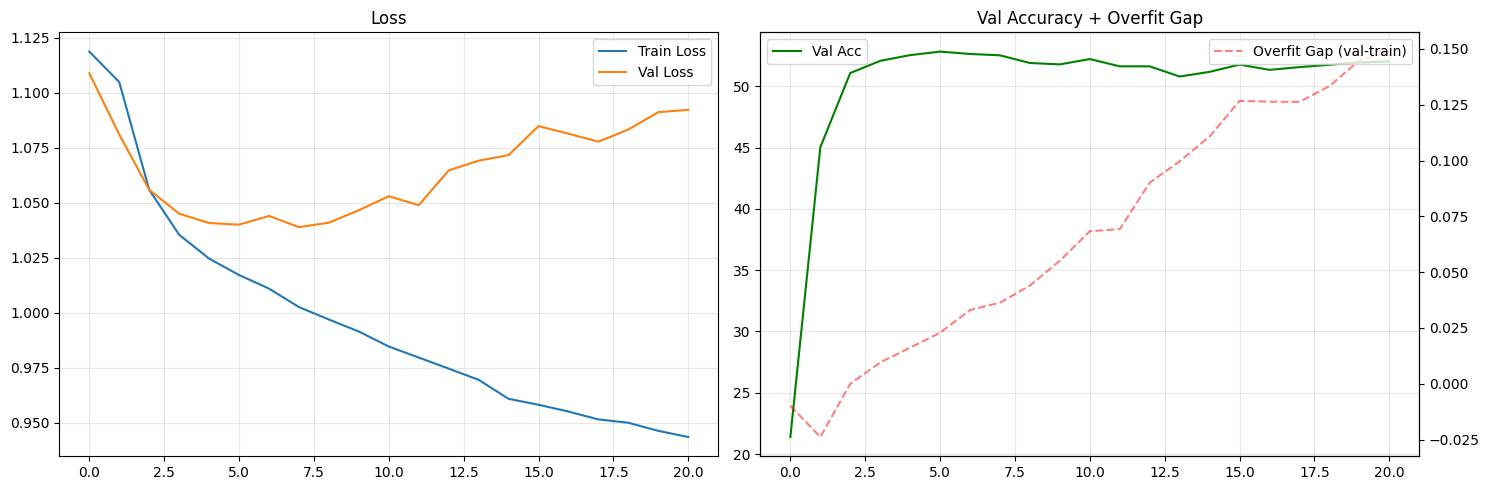

-------------------------------------------------------
                   precision    recall  f1-score   support

Vol Crush (<-15%)       0.62      0.57      0.59      2380
          Neutral       0.26      0.34      0.30      1336
Vol Expand (>15%)       0.64      0.59      0.61      2528

         accuracy                           0.53      6244
        macro avg       0.51      0.50      0.50      6244
     weighted avg       0.55      0.53      0.54      6244



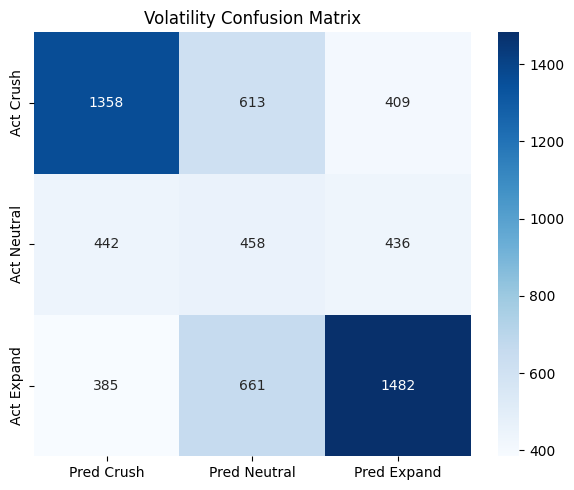

In [10]:
#Cell 10: Evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import sklearn.preprocessing._data

torch.serialization.add_safe_globals([sklearn.preprocessing._data.StandardScaler])
ckpt = torch.load(_MODEL_PATH, weights_only=False)
model.load_state_dict(ckpt['model'])
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for xd, xw, xm, yb in val_loader:
        xd, xw, xm = xd.to(device), xw.to(device), xm.to(device)
        preds = model(xd, xw, xm).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(yb.numpy())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'],   label='Val Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

gap = [v - t for t, v in zip(history['train_loss'], history['val_loss'])]
ax2.plot(history['val_acc'], label='Val Acc', color='green')
ax2_r = ax2.twinx()
ax2_r.plot(gap, label='Overfit Gap (val-train)', color='red', alpha=0.5, linestyle='--')
ax2.set_title('Val Accuracy + Overfit Gap')
ax2.legend(loc='upper left'); ax2_r.legend(loc='upper right')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("-" * 55)
# --- NEW: Volatility Labels ---
print(classification_report(all_targets, all_preds, target_names=["Vol Crush (<-15%)", "Neutral", "Vol Expand (>15%)"]))

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred Crush", "Pred Neutral", "Pred Expand"],
            yticklabels=["Act Crush", "Act Neutral", "Act Expand"])
plt.title('Volatility Confusion Matrix'); plt.tight_layout(); plt.show()